In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
folder_path = "climate_data"

files = [
    "alabama.csv","alaska.csv","arizona.csv","arkansas.csv","california.csv",
    "colorado.csv","conneticut.csv","delaware.csv","florida.csv","georgia.csv",
    "hawaii.csv","idaho.csv","illinois.csv","indiana.csv","iowa.csv",
    "kansas.csv","kentucky.csv","louisiana.csv","maine.csv","maryland.csv",
    "massachusetts.csv","michigan.csv","minnesota.csv","mississippi.csv",
    "missouri.csv","montana.csv","nebraska.csv","nevada.csv","newhampshire.csv",
    "newjersey.csv","newmexico.csv","newyork.csv","northcarolina.csv",
    "northdakota.csv","ohio.csv","oklahoma.csv","oregon.csv","pennsylvania.csv",
    "rhodeisland.csv","southcarolina.csv","southdakota.csv","tennessee.csv",
    "texas.csv","utah.csv","vermont.csv","virginia.csv","washington.csv",
    "westvirgina.csv","wisconsin.csv","wyoming.csv"
]

In [3]:
all_data = []

for file in files:
    path = os.path.join(folder_path, file)
    
    try:
        df = pd.read_csv(path, skiprows=2)  # 👈 skip the comment lines
        
        # Convert YYYYMM → datetime
        df["Date"] = pd.to_datetime(df["Date"], format="%Y%m")
        
        # Add state name
        state_name = file.replace(".csv", "")
        df["State"] = state_name
        
        all_data.append(df)
        print(f"Loaded: {file}")
    
    except Exception as e:
        print(f"Error with {file}: {e}")

combined_df = pd.concat(all_data, ignore_index=True)

combined_df.head()

Loaded: alabama.csv
Loaded: alaska.csv
Loaded: arizona.csv
Loaded: arkansas.csv
Loaded: california.csv
Loaded: colorado.csv
Loaded: conneticut.csv
Loaded: delaware.csv
Loaded: florida.csv
Loaded: georgia.csv
Loaded: hawaii.csv
Loaded: idaho.csv
Loaded: illinois.csv
Loaded: indiana.csv
Loaded: iowa.csv
Loaded: kansas.csv
Loaded: kentucky.csv
Loaded: louisiana.csv
Loaded: maine.csv
Loaded: maryland.csv
Loaded: massachusetts.csv
Loaded: michigan.csv
Loaded: minnesota.csv
Loaded: mississippi.csv
Loaded: missouri.csv
Loaded: montana.csv
Loaded: nebraska.csv
Loaded: nevada.csv
Loaded: newhampshire.csv
Loaded: newjersey.csv
Loaded: newmexico.csv
Loaded: newyork.csv
Loaded: northcarolina.csv
Loaded: northdakota.csv
Loaded: ohio.csv
Loaded: oklahoma.csv
Loaded: oregon.csv
Loaded: pennsylvania.csv
Loaded: rhodeisland.csv
Loaded: southcarolina.csv
Loaded: southdakota.csv
Loaded: tennessee.csv
Loaded: texas.csv
Loaded: utah.csv
Loaded: vermont.csv
Loaded: virginia.csv
Loaded: washington.csv
Loaded

,Date,Value,State
0,2016-01-01,43.0,alabama
1,2016-02-01,49.8,alabama
2,2016-03-01,59.7,alabama
3,2016-04-01,63.6,alabama
4,2016-05-01,70.2,alabama


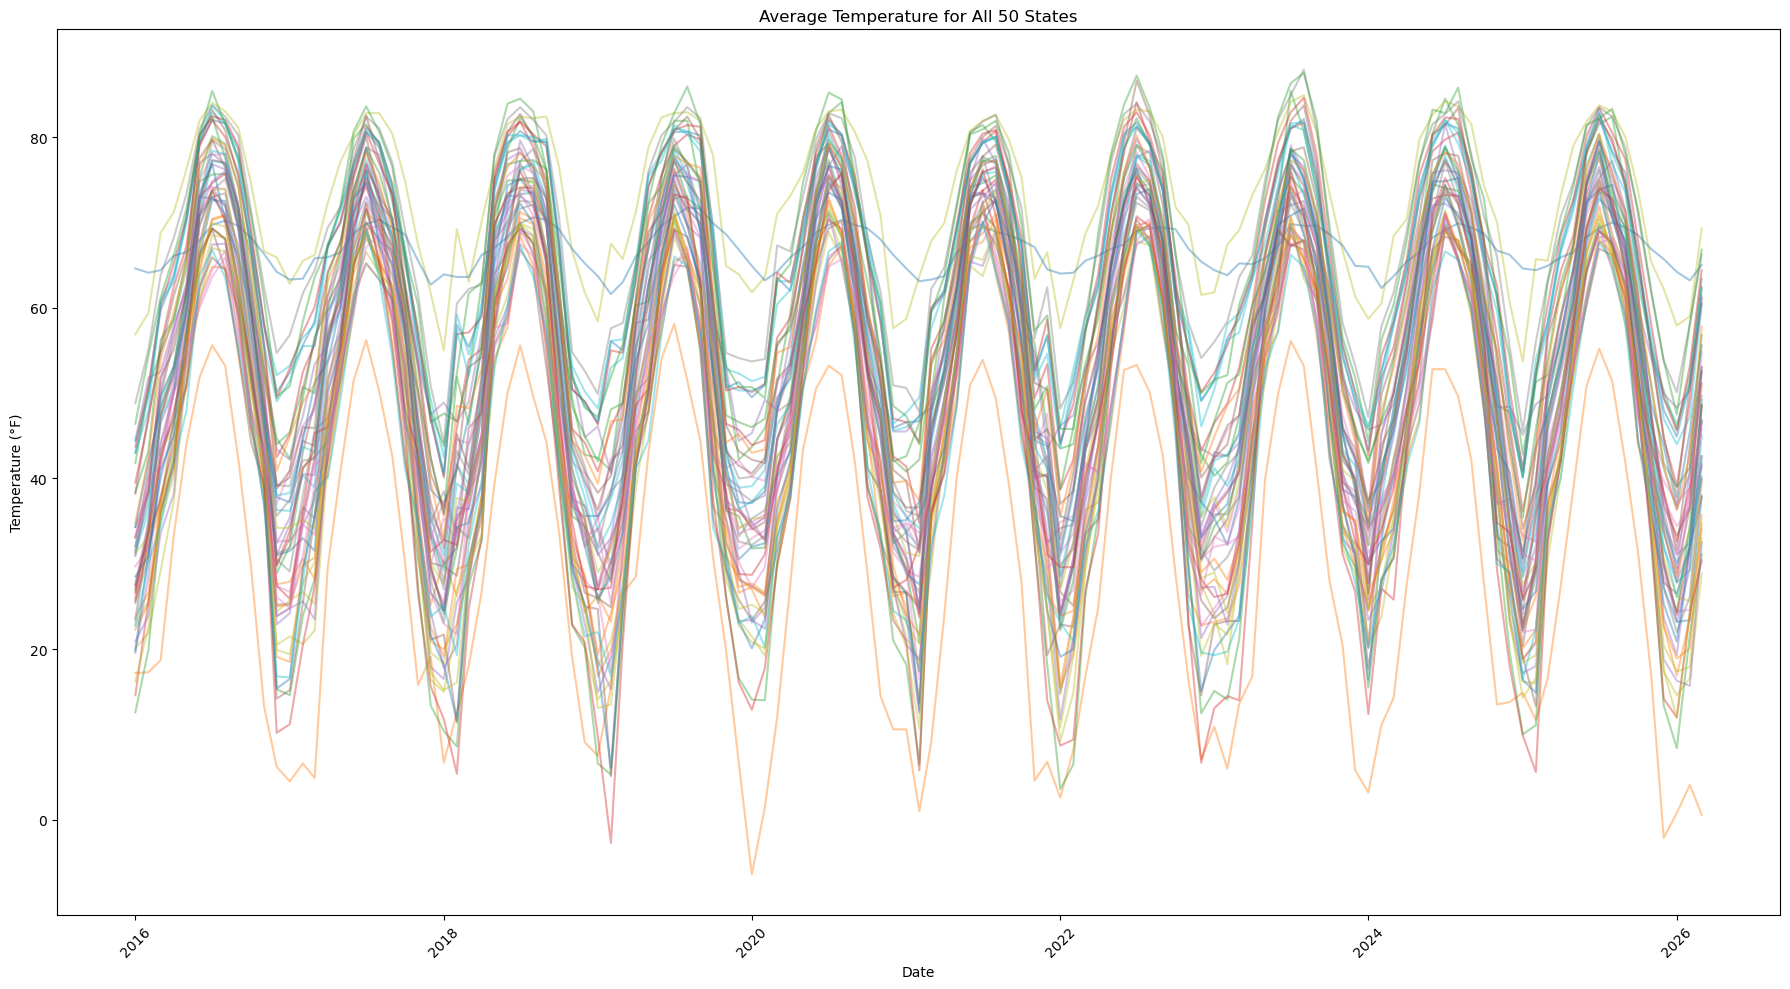

In [4]:
plt.figure(figsize=(18, 10))

for state in combined_df["State"].unique():
    state_df = combined_df[combined_df["State"] == state]
    
    plt.plot(
        state_df["Date"],
        state_df["Value"],
        alpha=0.4
    )

plt.title("Average Temperature for All 50 States")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

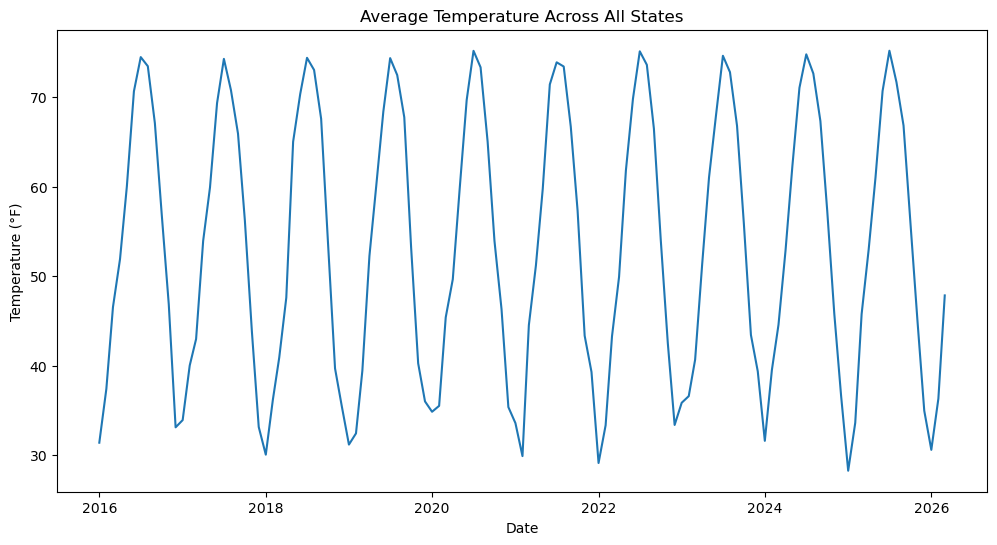

In [5]:
# plot national average instead
avg_df = combined_df.groupby("Date")["Value"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(avg_df["Date"], avg_df["Value"])
plt.title("Average Temperature Across All States")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.show()

In [6]:
region_map = {
    #West
    "california":"West","oregon":"West","washington":"West","nevada":"West",
    "arizona":"West","utah":"West","colorado":"West","idaho":"West",
    "montana":"West","wyoming":"West","alaska":"West","hawaii":"West",
    
    #Midwest
    "illinois":"Midwest","indiana":"Midwest","michigan":"Midwest","ohio":"Midwest",
    "wisconsin":"Midwest","minnesota":"Midwest","iowa":"Midwest","missouri":"Midwest",
    "kansas":"Midwest","nebraska":"Midwest","southdakota":"Midwest","northdakota":"Midwest",
    
    #South
    "texas":"South","oklahoma":"South","arkansas":"South","louisiana":"South",
    "mississippi":"South","alabama":"South","georgia":"South","florida":"South",
    "southcarolina":"South","northcarolina":"South","tennessee":"South","kentucky":"South",
    "virginia":"South","westvirgina":"South","maryland":"South","delaware":"South",
    
    #Northeast
    "newyork":"Northeast","newjersey":"Northeast","pennsylvania":"Northeast",
    "connecticut":"Northeast","rhodeisland":"Northeast","massachusetts":"Northeast",
    "vermont":"Northeast","newhampshire":"Northeast","maine":"Northeast"
}

combined_df["Region"] = combined_df["State"].map(region_map)

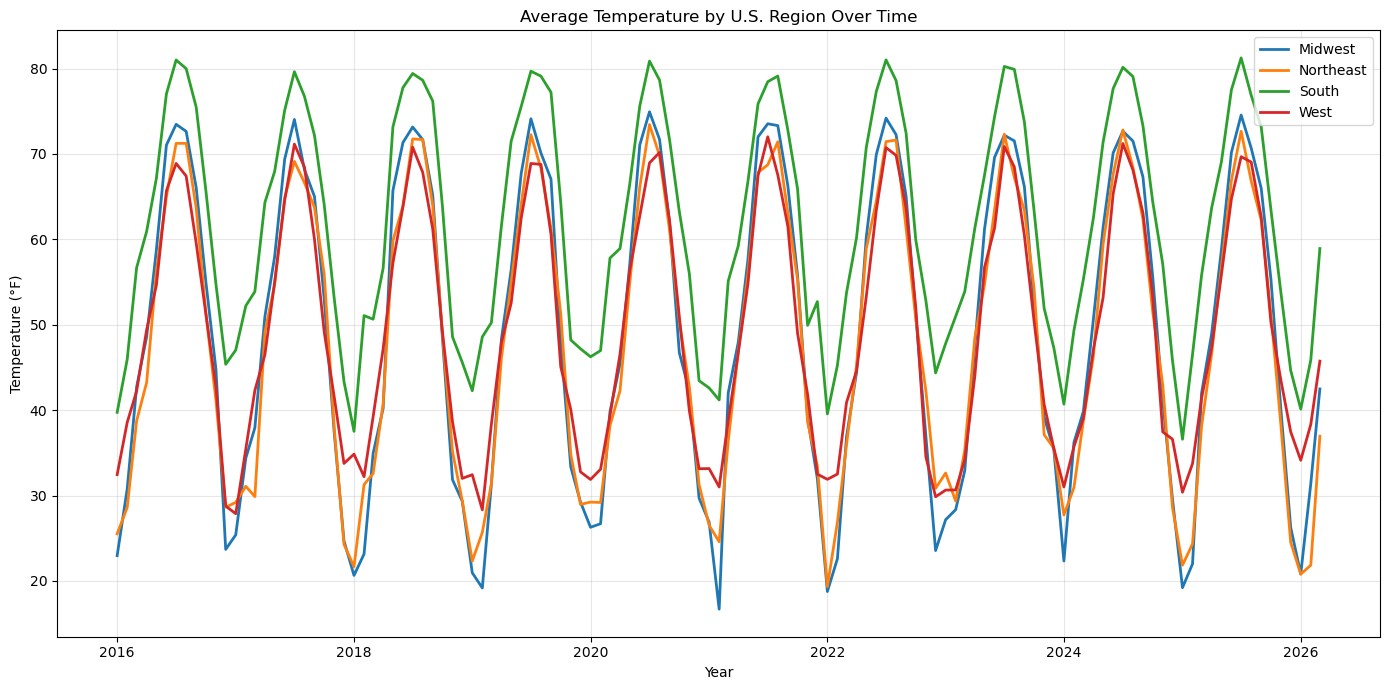

In [7]:
region_avg = combined_df.groupby(["Date", "Region"])["Value"].mean().reset_index()

plt.figure(figsize=(14,7))

for region in region_avg["Region"].dropna().unique():
    df = region_avg[region_avg["Region"] == region]
    
    plt.plot(df["Date"], df["Value"], linewidth=2, label=region)

plt.title("Average Temperature by U.S. Region Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import plotly.express as px

state_avg = combined_df.groupby("State")["Value"].mean().reset_index()

state_avg["State"] = state_avg["State"].replace({
    "conneticut": "connecticut",
    "westvirgina": "westvirginia"
})

state_abbrev = {
    "alabama":"AL","alaska":"AK","arizona":"AZ","arkansas":"AR","california":"CA",
    "colorado":"CO","connecticut":"CT","delaware":"DE","florida":"FL","georgia":"GA",
    "hawaii":"HI","idaho":"ID","illinois":"IL","indiana":"IN","iowa":"IA",
    "kansas":"KS","kentucky":"KY","louisiana":"LA","maine":"ME","maryland":"MD",
    "massachusetts":"MA","michigan":"MI","minnesota":"MN","mississippi":"MS",
    "missouri":"MO","montana":"MT","nebraska":"NE","nevada":"NV","newhampshire":"NH",
    "newjersey":"NJ","newmexico":"NM","newyork":"NY","northcarolina":"NC",
    "northdakota":"ND","ohio":"OH","oklahoma":"OK","oregon":"OR","pennsylvania":"PA",
    "rhodeisland":"RI","southcarolina":"SC","southdakota":"SD","tennessee":"TN",
    "texas":"TX","utah":"UT","vermont":"VT","virginia":"VA","washington":"WA",
    "westvirginia":"WV","wisconsin":"WI","wyoming":"WY"
}

state_avg["abbr"] = state_avg["State"].map(state_abbrev)

print(state_avg.head())
print("Missing abbreviations:", state_avg["abbr"].isna().sum())

fig = px.choropleth(
    state_avg,
    locations="abbr",
    locationmode="USA-states",
    color="Value",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"Value": "Avg Temp (°F)"},
    title="Average Temperature by State"
)

fig.show()

        State      Value abbr
0     alabama  64.569919   AL
1      alaska  28.664228   AK
2     arizona  61.789431   AZ
3    arkansas  61.723577   AR
4  california  59.743089   CA
Missing abbreviations: 0
